# Study Area Visualization with Simplified LULC

This code visualizes the study area using land use and land cover (LULC) data, based on the previously generated *Resample_Yearly_LULC.ipynb*.

Since the original LULC dataset contains a large number of categories, directly plotting it results in a visually complex figure. To improve clarity, similar classes were grouped and non-essential categories were removed, resulting in seven representative categories for visualization.

As a representative example, the LULC data from 2022, the most recent year within the study period, were used for plotting.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pdL
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Develop a function to plot the North Polar region
With minor modifications to better represent the study area and its vegetation characteristics.


In [2]:
def plot_Northpole_with_gridlabels(domain_lon, domain_lat, data,
                                      label_title="",
                                      cmap="viridis",
                                      vmin=None, vmax=None, vcenter=None,
                                      norm=None,
                                      bounds=None, ticks=None, ticklabels=None,
                                      central_lon=0,
                                      draw_grid_labels=True,
                                      shading="auto",
                                      lon_grid_interval=60,
                                      lat_grid_interval=5,
                                      figsize=(10, 10),
                                      ocean_color='powderblue',
                                      land_color='lightgray',
                                      coast_linewidth=0.5):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=central_lon))

    theta = np.linspace(0, 2 * np.pi, 200)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([central_lon - 180, central_lon + 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, zorder=0)
    ax.add_feature(cfeature.LAND, facecolor=land_color, edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=coast_linewidth, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    if norm is None:
        if bounds is None:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        else:
            norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading=shading
    )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=draw_grid_labels,
        linewidth=0.8,
        color='gray',
        alpha=0.5,
        linestyle='--',
        xlocs=np.arange(-180, 181, lon_grid_interval),
        ylocs=np.arange(60, 91, lat_grid_interval),
        zorder=4
    )

    if draw_grid_labels:
        gl.top_labels = True
        gl.bottom_labels = True
        gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {'size': 12, 'color': 'black'}
        gl.ylabel_style = {'size': 12, 'color': 'black'}

    plt.show()
    return fig, ax, mesh

In [3]:
# To enhance the visual presentation of the figure, the legend is displayed separately.
def plot_grouped_lulc_legend(labels, colors,
                             legend_title="Grouped LULC",
                             figsize=(4.8, 2.6),
                             ncol=1,
                             fontsize=11,
                             title_fontsize=13,
                             frameon=True):

    handles = [
        Patch(facecolor=c, edgecolor='none', label=l)
        for c, l in zip(colors, labels)
    ]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    ax.axis("off")

    legend = ax.legend(
        handles=handles,
        title=legend_title,
        loc="center",
        ncol=ncol,
        frameon=frameon,
        fontsize=fontsize,
        title_fontsize=title_fontsize
    )

    plt.show()
    return fig, ax, legend

## Original LULC Categories

The original LULC classification scheme was derived from the *Product User Guide and Specification* of the *CDR and ICDR Sentinel-3 Land Cover (v2.1.1)* dataset, available from the Copernicus Climate Data Store (CDS).

<img src="../Git_figures/LULC_original_class.png" width="1500">

The original classes were grouped into similar categories, and classes with comparable characteristics were combined where appropriate (e.g., lichens and mosses). 

Additionally, cropland, broadleaf forest, mixed forest, and mosaic classes were aggregated into an "Others" category to improve visual clarity and allow for a more concise representation.

In [4]:
# Final Group ID (2,3,7,9,10,11,13)
CCI2A_GROUP = {
    10:0, 20:0, 30:0, 40:0,          # Cropland
    50:1, 60:1, 61:1, 62:1,          # Broadleaf
    70:2, 71:2, 72:2,                # Needleleaf evergreen
    80:3, 81:3, 82:3,                # Needleleaf deciduous
    90:4,                            # Mixed
    100:5,                           # Mosaic tree/shrub
    110:6,                           # Mosaic herb/tree
    120:7, 121:7, 122:7,             # Shrubland
    130:8,                           # Grassland
    140:9,                           # Lichens & mosses
    150:10, 151:10, 152:10, 153:10,  # Sparse vegetation
    160:11, 170:11, 180:11,          # Wetlands
    200:12, 201:12, 202:12,          # Bare areas
}


# ---- Final group IDs used in plots ----
# 2: Needleleaf evergreen forest
# 3: Needleleaf deciduous forest
# 7: Shrubland / Grassland     (merged)
# 9: Lichens & mosses
# 11: Wetlands / flooded veg.
# 10: Sparse vegetation / Bare areas  (merged)
# 13: Others (Cropland + Broadleaf + Mixed + Mosaic)

GROUP_RULES = {
    # Merge pairs
    "merge_map": {
        8: 7,    # Grassland -> Shrubland/Grassland
        12: 10,  # Bare -> Sparse/Bare
    },
    # Send these groups to Others
    "others_groups": {0, 1, 4, 5, 6},
    "others_id": 13,
}

A_GROUP_LABELS_FINAL = {
    2:  "Needleleaf evergreen forest",
    3:  "Needleleaf deciduous forest",
    7:  "Shrubland / Grassland",
    9:  "Lichens & mosses",
    11: "Wetlands / flooded veg.",
    10: "Sparse vegetation / Bare areas",
    13: "Others",
}

A_GROUP_PALETTE_FINAL = {
    2:  "#1B7837",  # evergreen forest (deep green)
    3:  "#5AAE61",  # deciduous forest (lighter green)
    7:  "#D55E00",  # shrub / grass
    9:  "#6A3D9A",  # lichens & mosses
    11: "#00BFC4",  # wetlands
    10: "#DFC27D",  # sparse / bare
    13: "#2B2B2B",  # others
}

A_LEGEND_ORDER_FINAL = [2, 3, 7, 9, 11, 10, 13]


In [ ]:
def cci_to_groupA_final(data_int, *, mask_codes=(210, 220), fill_value=np.nan):
    """
    ESA-CCI LULC code -> Final Group ID (2,3,7,9,10,11,13)
    """
    data = np.asarray(data_int)
    out = np.full(data.shape, fill_value, dtype=float)

    valid = np.isfinite(data)
    if not np.any(valid):
        return out

    # 1) Extract valid pixels into 1D array
    codes = data[valid].astype(int)

    # 2) Mask out water/snow/ice
    keep = ~np.isin(codes, list(mask_codes))
    mapped = np.full(codes.shape, fill_value, dtype=float)

    # 3) Convert original LULC codes to simplified group IDs
    base_gid = np.array([CCI2A_GROUP.get(int(c), -999) for c in codes[keep]], dtype=int)

    # 4) Drop unmapped
    ok = base_gid != -999
    gid = base_gid[ok]

    # 5) Merge rules (8->7, 12->10)
    merge_map = GROUP_RULES["merge_map"]
    gid = np.array([merge_map.get(int(g), int(g)) for g in gid], dtype=int)

    # 6) Define Others rules
    gid = np.where(np.isin(gid, list(GROUP_RULES["others_groups"])),
                   GROUP_RULES["others_id"], gid)

    # 7) Put back into mapped 
    keep_idx = np.where(keep)[0]
    mapped[keep_idx[ok]] = gid.astype(float)

    # 8) Write back into 2D output
    out[valid] = mapped
    return out



def add_groupA_legend_right(fig, present_groups, labels, cmap, *,
                            title="Grouped LULC",
                            ncol=1, anchor=(0.88, 0.45),
                            fontsize=12, title_fontsize=13,
                            handleheight=1.2, labelspacing=0.8,
                            handletextpad=0.8,   # 색 박스-텍스트 간격
                            borderpad=1.2,       # legend 내부 여백(타이틀 포함)
                            borderaxespad=0.0):  # figure/axes와의 바깥 여백
    handles = [Patch(facecolor=cmap.colors[i], edgecolor='none')
               for i in range(len(present_groups))]

    leg = fig.legend(
        handles, labels, title=title,
        loc="center left", bbox_to_anchor=anchor,
        frameon=False, ncol=ncol,
        fontsize=fontsize, title_fontsize=title_fontsize,
        handleheight=handleheight,
        labelspacing=labelspacing,
        handletextpad=handletextpad,
        borderpad=borderpad,
        borderaxespad=borderaxespad,
    )
    return leg

### Figure 11a - Map

unique group ids in map: [ 2  3  7  9 10 11 13]
counts: {np.int64(2): 8836, np.int64(3): 11181, np.int64(7): 5362, np.int64(9): 5014, np.int64(10): 13179, np.int64(11): 1944, np.int64(13): 2198}
nan ratio: 0.7238773148148148


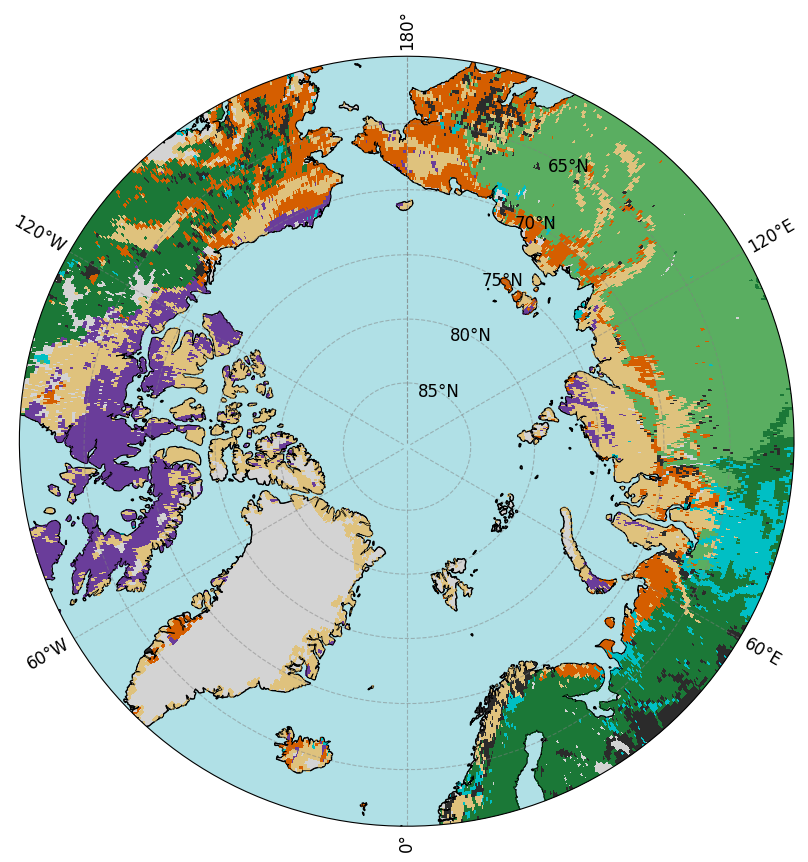

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Grouped_LULC_60N_2022.png


In [6]:
LULC_file = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/ESA_CCI_LULC_25km_60N_1992_2022.nc"

# --- Final legend order (only final groups)
A_LEGEND_ORDER = [2, 3, 7, 9, 11, 10, 13]

# --- Ensure merged labels 
A_GROUP_LABELS_FINAL[7]  = "Shrubland / Grassland"
A_GROUP_LABELS_FINAL[10] = "Sparse vegetation / Bare areas"
A_GROUP_LABELS_FINAL[13] = "Others"

# 1) Read LULC (2022)
with nc.Dataset(LULC_file) as ds:
    latv = ds.variables["lat"][:] if "lat" in ds.variables else ds.variables["latitude"][:]
    lonv = ds.variables["lon"][:] if "lon" in ds.variables else ds.variables["longitude"][:]
    LULC = ds.variables["lccs_class"][:, :, -1]  # 2022 (lat, lon)

# 2) Make 1D lat/lon if stored as 2D
if latv.ndim == 2 and lonv.ndim == 2:
    lat = latv[:, 0]
    lon = lonv[0, :]
else:
    lat = latv
    lon = lonv

# 3) Wrap/sort longitude and reorder LULC
if np.nanmax(lon) > 180:
    lon_wrapped = _wrap180(lon)
    idx = np.argsort(lon_wrapped)
    lon = lon_wrapped[idx]
    LULC = LULC[:, idx]

lon2d, lat2d = np.meshgrid(lon, lat)

# 4) Convert CCI codes -> Final Group IDs (2,3,7,9,10,11,13)
groupA_map = cci_to_groupA_final(LULC, mask_codes=(210, 220), fill_value=np.nan)

# 5) Reindex group IDs -> plot indices (0..N-1) based on legend order
order = A_LEGEND_ORDER
gid_to_idx = {gid: i for i, gid in enumerate(order)}

plot_map = np.full(groupA_map.shape, np.nan, dtype=float)
for gid, ii in gid_to_idx.items():
    plot_map[groupA_map == gid] = ii

# 6) Colormap/norm for plot_map indices
colors = [A_GROUP_PALETTE_FINAL[g] for g in order]
labels = [A_GROUP_LABELS_FINAL[g] for g in order]

cmap = ListedColormap(colors, name="cci_groupA_final_indexed")
bounds = np.arange(-0.5, len(order) + 0.5, 1.0)
norm = BoundaryNorm(bounds, cmap.N)

u = np.unique(groupA_map[np.isfinite(groupA_map)]).astype(int)
print("unique group ids in map:", u)
print("counts:", {k: int(np.sum(groupA_map == k)) for k in u})
print("nan ratio:", np.mean(~np.isfinite(groupA_map)))


# 7) Plot
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]

legend_labels = [
    "Needleleaf evergreen forest",
    "Needleleaf deciduous forest",
    "Shrubland / Grassland",
    "Lichens & mosses",
    "Wetlands / flooded veg.",
    "Sparse vegetation / Bare areas",
    "Others"
]

fig, ax, mesh = plot_Northpole_with_gridlabels(
    lon2d, lat2d, plot_map,
    label_title="",
    cmap=cmap,
    norm=norm,
    central_lon=0,
    draw_grid_labels=True,
    shading="auto"
)

out_png = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Grouped_LULC_60N_2022.png"

fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

print("Saved:", out_png)


plt.show()



### Figure 11a - Legend

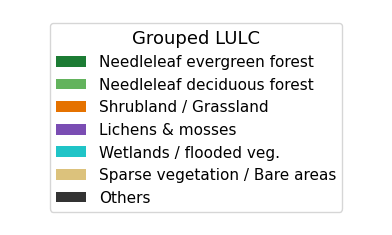

In [8]:
lulc_labels = [
    "Needleleaf evergreen forest",
    "Needleleaf deciduous forest",
    "Shrubland / Grassland",
    "Lichens & mosses",
    "Wetlands / flooded veg.",
    "Sparse vegetation / Bare areas",
    "Others"
]

lulc_colors = [
    "#1c7c34",  # dark green
    "#63b35d",  # light green
    "#e57200",  # orange
    "#7a4db3",  # purple
    "#20c4c7",  # cyan
    "#dcc27c",  # beige
    "#333333"   # dark gray
]

fig_leg, ax_leg, legend = plot_grouped_lulc_legend(
    labels=lulc_labels,
    colors=lulc_colors,
    legend_title="Grouped LULC",
    figsize=(4.8, 2.8),
    ncol=1,
    fontsize=11,
    title_fontsize=13
)
fig_leg.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Grouped_LULC_Legend.png", dpi=300, bbox_inches="tight", transparent=True)